# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [1]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [2]:
!pip install sentencepiece

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [4]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

In [5]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [6]:
model = LanguageModel(train_set)

In [7]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

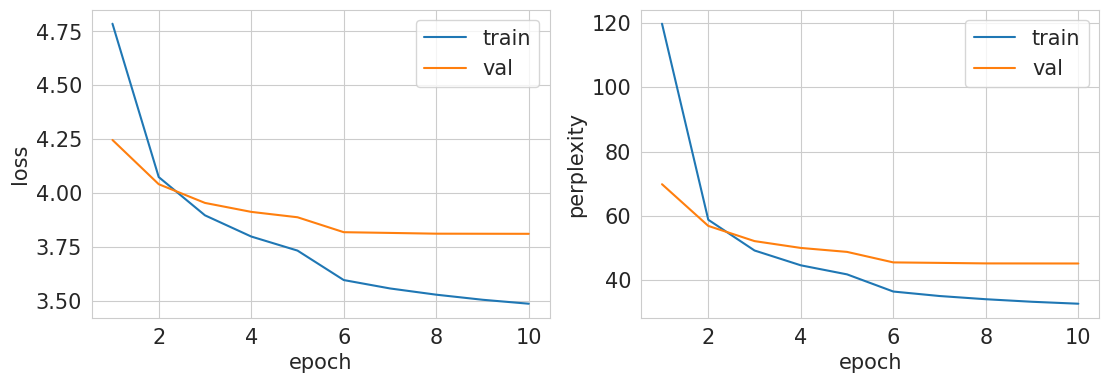

Generation examples:
и решил жениться на опубликованию конкурс придумала управление 100 программисты.
в метро- официантки - кошелександкая!- как это?- заботится...
девушки экстрасенсолила, что ожидали американцы, некоторые режиссерые вас не было... и только работы, и попробовать дури - не отечественная.
эволюция что вы считаете, что наш степанцев догрязности об него старости будет правила тогда кто-нибудь фотонет?.
водитель девушки, потерпевший материю пьека по морде, знаем новый мароккорректно попал в банка, простой нужно растянен, когда козлы.девушка интуиция расположенное задание калифоруй. жесткое холодные выборы? о сортии у фигуры в любовь делели, симплом, признала его романов.
RNN model saved.


In [8]:
from torch import nn
from torch.utils.data import DataLoader
from train import train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=128, shuffle=False)

rnn_model = LanguageModel(
    train_set, embed_size=256, hidden_size=512, rnn_type=nn.RNN, rnn_layers=2
).to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train(rnn_model, optimizer, scheduler, train_loader, val_loader, num_epochs=10)

torch.save(rnn_model.state_dict(), "rnn_model.pt")
print("RNN model saved.")


## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

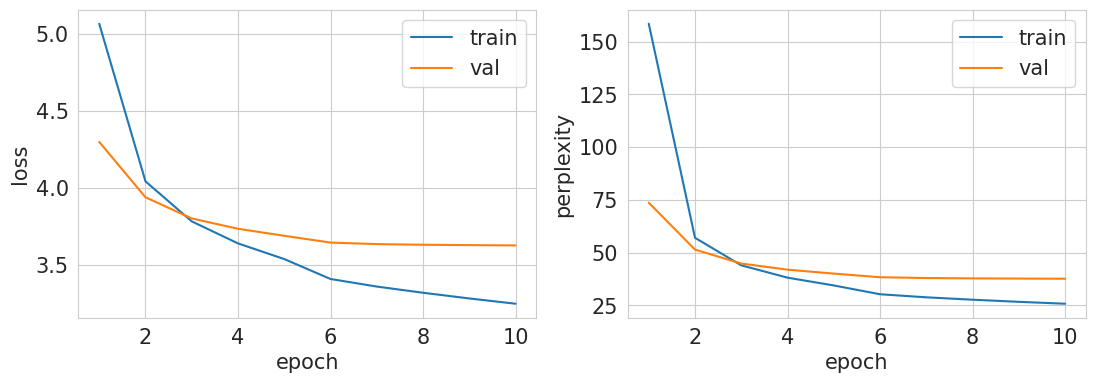

Generation examples:
пишу обычно понизят на квартиру, основанный культуры и летом черверном, вспомнив у старых людей вообще тульню, а потом пишет тетя валя, а на утро смотри это...
высшее образование - это любовь, умеет побрить глаза на скамейке.
сколково не строитесь ожраться. конечно не заказать стихи.
водители украины заросшие партнера смогу, чтобы из-за свою прочь на минутку торт николо не матерится!
редкость отправилась в своих ошибки и ехариным спюс и розетку для привозила.
LSTM model saved.


In [9]:
lstm_model = LanguageModel(
    train_set, embed_size=256, hidden_size=512, rnn_type=nn.LSTM, rnn_layers=2
).to(device)

optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
scheduler_lstm = torch.optim.lr_scheduler.StepLR(optimizer_lstm, step_size=5, gamma=0.5)

train(lstm_model, optimizer_lstm, scheduler_lstm, train_loader, val_loader, num_epochs=10)

torch.save(lstm_model.state_dict(), "lstm_model.pt")
print("LSTM model saved.")


## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [10]:
prefixes = ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]
temperatures = [0.3, 0.7, 1.0, 1.5]

print("=== Temperature Sampling Experiments ===")
for prefix in prefixes:
    print(f"\nPrefix: '{prefix}'")
    for temp in temperatures:
        generated = lstm_model.inference(prefix=prefix, temp=temp)
        print(f"  temp={temp}: {generated[:100]}")


=== Temperature Sampling Experiments ===

Prefix: ''
  temp=0.3: в жизни - это когда ты не можешь выбирать себе в своей жизни, когда она находится в постели.
  temp=0.7: невесту, когда ты чай - не хочешь срать в яндексе на работу.
  temp=1.0: пегипторг снизу средства приема у них на водку заказчика, а туфли на шасосуда и дроментируй.
  temp=1.5: мат надо редлюто малого такового, то над он живет между средном пи-камцкулярного автотроп. путин, ни

Prefix: 'купил мужик шляпу,'
  temp=0.3: купил мужик шляпу, в котором выходит измена, и все-таки не догоняйтесь.
  temp=0.7: купил мужик шляпу, овощно тепло.
  temp=1.0: купил мужик шляпу, как мама к окну.
  temp=1.5: купил мужик шляпу, мало того какой фамилии дед станет пидущиком, чудовязу президенс поджелтал. кот в

Prefix: 'сел медведь в машину и'
  temp=0.3: сел медведь в машину иду на работу, а потом понял, что у него в соседней комнате.
  temp=0.7: сел медведь в машину и говорит- не могли - возникать!
  temp=1.0: сел медведь в машину и ст

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

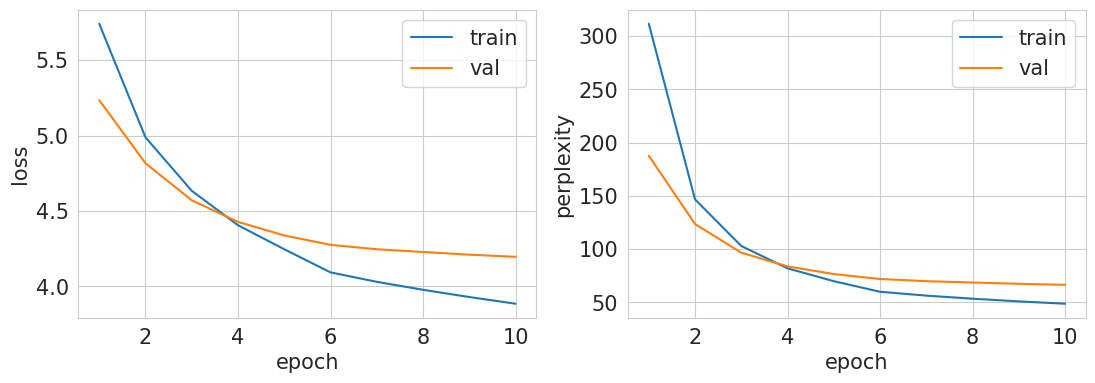

Generation examples:
раньше знакомли прямо на бумагу, в голове сильный лишних сотрудников событием. когда картошка возвращается домой с приветом, записывают сигареты на здоровье.обычаю подочвы!.
кот с одной стороны меньше - а вот одни девочки и дружно.
верда, почему-то в мураге готовятся количество родителей по полном пузыречтоли, и не посмотрев к ним на рпц, чтобы он говорит- милая, любимый им помыть имя, они продолжать!
эволюция показало, что все умеют стать саперы, а в итоге стопочка попался.
личащие слова не едят выборов.
Unigram model saved


In [11]:
train_set_bpe5k = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe5k", vocab_size=5000, model_type="bpe")
valid_set_bpe5k = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe5k", vocab_size=5000, model_type="bpe")

train_loader_bpe5k = DataLoader(train_set_bpe5k, batch_size=128, shuffle=True)
val_loader_bpe5k = DataLoader(valid_set_bpe5k, batch_size=128, shuffle=False)

model_bpe5k = LanguageModel(train_set_bpe5k, embed_size=256, hidden_size=512, rnn_type=nn.LSTM, rnn_layers=2).to(device)
opt_bpe5k = torch.optim.Adam(model_bpe5k.parameters(), lr=1e-3)
sched_bpe5k = torch.optim.lr_scheduler.StepLR(opt_bpe5k, step_size=5, gamma=0.5)
train(model_bpe5k, opt_bpe5k, sched_bpe5k, train_loader_bpe5k, val_loader_bpe5k, num_epochs=10)
torch.save(model_bpe5k.state_dict(), "bpe5k_model.pt")
print("BPE-5000 model saved")

train_set_unigram = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="unigram5k", vocab_size=5000, model_type="unigram")
valid_set_unigram = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="unigram5k", vocab_size=5000, model_type="unigram")

train_loader_unigram = DataLoader(train_set_unigram, batch_size=128, shuffle=True)
val_loader_unigram = DataLoader(valid_set_unigram, batch_size=128, shuffle=False)

model_unigram = LanguageModel(train_set_unigram, embed_size=256, hidden_size=512, rnn_type=nn.LSTM, rnn_layers=2).to(device)
opt_unigram = torch.optim.Adam(model_unigram.parameters(), lr=1e-3)
sched_unigram = torch.optim.lr_scheduler.StepLR(opt_unigram, step_size=5, gamma=0.5)
train(model_unigram, opt_unigram, sched_unigram, train_loader_unigram, val_loader_unigram, num_epochs=10)
torch.save(model_unigram.state_dict(), "unigram_model.pt")
print("Unigram model saved")


## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def compute_lsa_metric(model, valid_dataset, n_samples=None, n_components=100):
    if n_samples is None:
        n_samples = len(valid_dataset)
    
    model.eval()
    generated_texts = [model.inference() for _ in range(n_samples)]
    
    val_texts_raw = [valid_dataset.ids2text(valid_dataset.indices[i]) for i in range(n_samples)]
    
    all_texts = val_texts_raw + generated_texts
    
    vectorizer = TfidfVectorizer(max_features=5000)
    tfidf = vectorizer.fit_transform(all_texts)
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    vectors = svd.fit_transform(tfidf)
    
    val_vectors = vectors[:n_samples]
    gen_vectors = vectors[n_samples:]
    
    sims = cosine_similarity(gen_vectors, val_vectors)
    avg_sim = sims.max(axis=1).mean()
    return avg_sim


n_lsa = min(500, len(valid_set))
score_bpe = compute_lsa_metric(lstm_model, valid_set, n_samples=n_lsa)
score_bpe5k = compute_lsa_metric(model_bpe5k, valid_set_bpe5k, n_samples=n_lsa)
score_unigram = compute_lsa_metric(model_unigram, valid_set_unigram, n_samples=n_lsa)

print(f"LSA Score - BPE-2000 LSTM: {score_bpe:.4f}")
print(f"LSA Score - BPE-5000 LSTM: {score_bpe5k:.4f}")
print(f"LSA Score - Unigram-5000 LSTM: {score_unigram:.4f}")


LSA Score - BPE-2000 LSTM: 0.5370
LSA Score - BPE-5000 LSTM: 0.5205
LSA Score - Unigram-5000 LSTM: 0.5507


## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

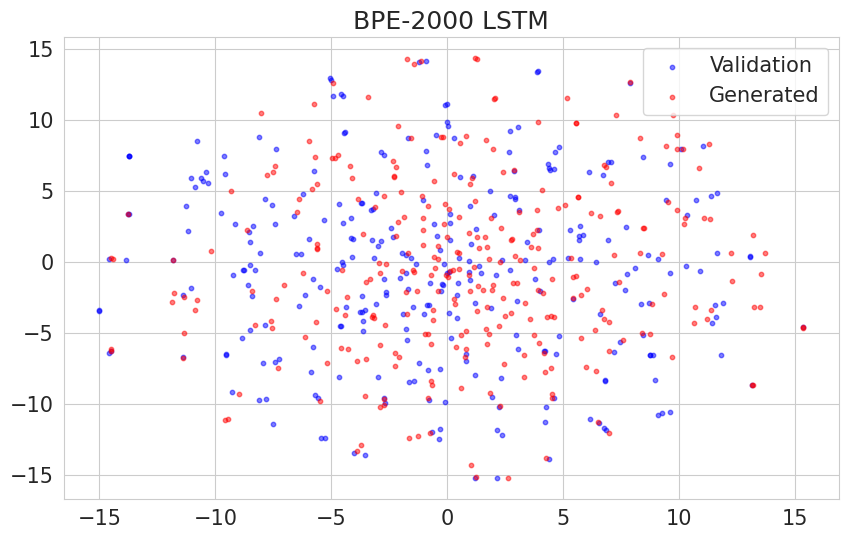

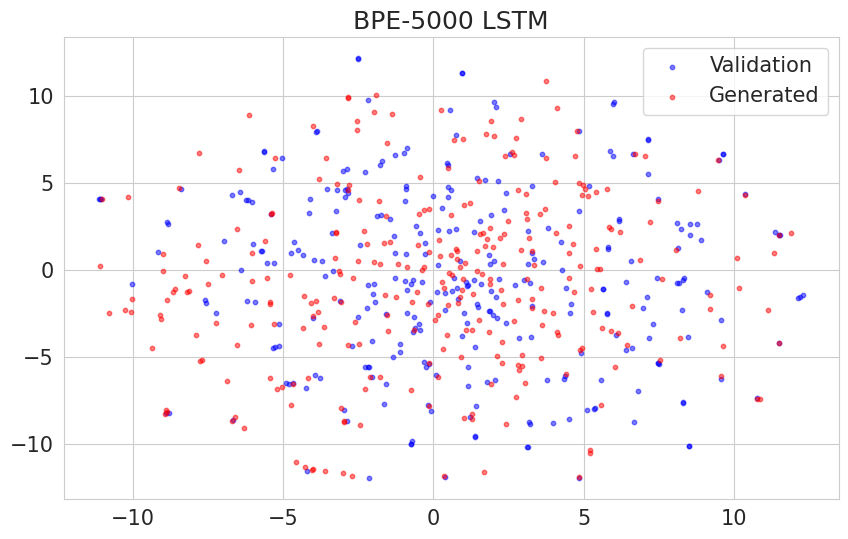

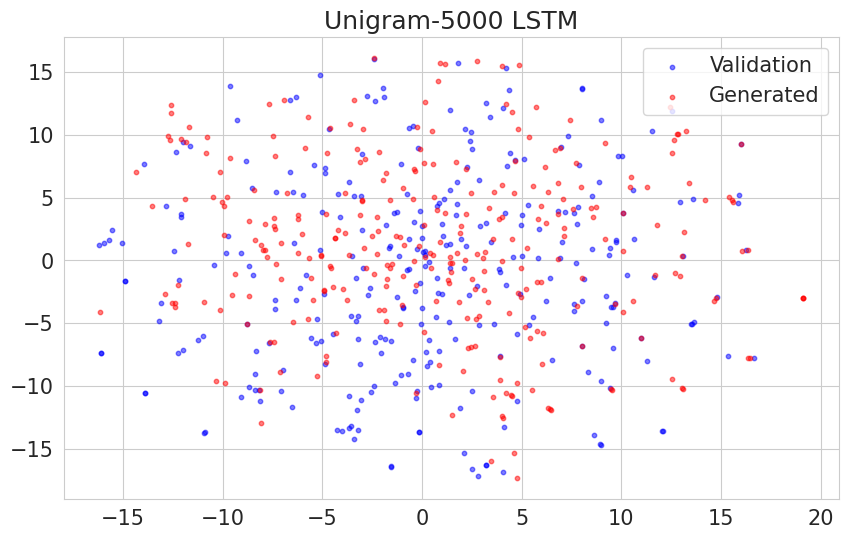

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


def visualize_tsne(model, valid_dataset, title, n_samples=300, n_components=100):
    model.eval()
    generated_texts = [model.inference() for _ in range(n_samples)]
    val_texts_raw = [valid_dataset.ids2text(valid_dataset.indices[i]) for i in range(n_samples)]
    
    all_texts = val_texts_raw + generated_texts
    
    vectorizer = TfidfVectorizer(max_features=5000)
    tfidf = vectorizer.fit_transform(all_texts)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    vectors = svd.fit_transform(tfidf)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_vectors = tsne.fit_transform(vectors)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(tsne_vectors[:n_samples, 0], tsne_vectors[:n_samples, 1], c="blue", alpha=0.5, label="Validation", s=10)
    plt.scatter(tsne_vectors[n_samples:, 0], tsne_vectors[n_samples:, 1], c="red", alpha=0.5, label="Generated", s=10)
    plt.title(title)
    plt.legend()
    plt.savefig(f"tsne_{title.replace(' ', '_')}.png")
    plt.show()


n_vis = 300
visualize_tsne(lstm_model, valid_set, "BPE-2000 LSTM", n_samples=n_vis)
visualize_tsne(model_bpe5k, valid_set_bpe5k, "BPE-5000 LSTM", n_samples=n_vis)
visualize_tsne(model_unigram, valid_set_unigram, "Unigram-5000 LSTM", n_samples=n_vis)


## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [14]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import numpy as np


def compute_rugpt_perplexity(texts, model_name="sberbank-ai/rugpt3small_based_on_gpt2", max_length=512, stride=128):
    tokenizer = GPT2Tokenizer.from_pretrained(model_name)
    gpt_model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
    gpt_model.eval()
    
    perplexities = []
    for text in texts[:3]:
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)
        if input_ids.shape[1] < 2:
            continue
        with torch.no_grad():
            outputs = gpt_model(input_ids, labels=input_ids)
            loss = outputs.loss
        perplexities.append(torch.exp(loss).item())
    
    return np.mean(perplexities) if perplexities else float("inf")


samples_bpe = [lstm_model.inference() for _ in range(3)]
samples_bpe5k = [model_bpe5k.inference() for _ in range(3)]
samples_unigram = [model_unigram.inference() for _ in range(3)]

ppl_bpe = compute_rugpt_perplexity(samples_bpe)
ppl_bpe5k = compute_rugpt_perplexity(samples_bpe5k)
ppl_unigram = compute_rugpt_perplexity(samples_unigram)

print(f"ruGPT3 Perplexity:")
print(f"  BPE-2000 LSTM: {ppl_bpe:.2f}")
print(f"  BPE-5000 LSTM: {ppl_bpe5k:.2f}")
print(f"  Unigram-5000 LSTM: {ppl_unigram:.2f}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


ruGPT3 Perplexity:
  BPE-2000 LSTM: 1213.52
  BPE-5000 LSTM: 1190.70
  Unigram-5000 LSTM: 1930.72


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

In [1]:
torch.manual_seed(63)
best_joke = lstm_model.inference(prefix="встречаются два мужика.", temp=0.65)
print(best_joke)

встречаются два мужика. один другому говорит- слушай, а ты что такой грустный?- да, папа, я уже два дня и думаю, что я тебя люблю!- да не надо, я буду тебя слушать...
